In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 파일이 같은 notebooks 폴더에 있으므로 이름만 적어서 불러옵니다.
df_2021 = pd.read_csv('final_crisis_index_by_dong_2021.csv')

# 2. CCI 상위 10개 행정동 추출
cols_cci = ['자치구명', '행정동명', 'IVI', 'CDI', 'RII', 'CCI', 'CCI_rank', 'risk_type', 'triple_high_flag']
top_10_cci = df_2021.nlargest(10, 'CCI')[cols_cci]

print("--- CCI 상위 10개 행정동 ---")
display(top_10_cci)

# 상위 10개 중 triple_high_flag가 0인 지역 (최고위험지역이 아닌 곳) 확인
not_triple_high = top_10_cci[top_10_cci['triple_high_flag'] == 0]
print("\n--- CCI 상위권 중 복합위기 최고위험지역이 아닌 예시 ---")
display(not_triple_high)

# 3. 잃어버린 파일 대신, 메인 데이터에서 직접 최고위험지역 11개 추출하기!
# triple_high_flag == 1 인 지역만 필터링합니다.
top_risk_df = df_2021[df_2021['triple_high_flag'] == 1]

print("\n--- 최종 복합위기 최고위험지역 11개 목록 (직접 추출) ---")
# 11개가 맞는지 확인하기 위해 필요한 컬럼만 예쁘게 뽑아줍니다.
display(top_risk_df[['자치구명', '행정동명', 'IVI', 'CDI', 'RII', 'CCI', 'risk_type']])

--- CCI 상위 10개 행정동 ---


,자치구명,행정동명,IVI,CDI,RII,CCI,CCI_rank,risk_type,triple_high_flag
158,노원구,월계2동,0.549033,0.951123,0.642672,0.714276,1,복합위기 최고위험지역,1
251,강서구,가양2동,0.780162,0.947160,0.392315,0.706546,2,복합위기 최고위험지역,1
131,강북구,번2동,0.722707,0.974901,0.391465,0.696358,3,복합위기 최고위험지역,1
132,강북구,번3동,0.810017,0.956407,0.261363,0.675929,4,사회고립+인프라취약형,0
373,강남구,수서동,0.822365,0.919419,0.261363,0.667716,5,사회고립 단일취약형,0
116,성북구,정릉3동,0.498643,0.955086,0.524695,0.659475,6,복합위기 최고위험지역,1
155,도봉구,도봉1동,0.643987,0.852048,0.478237,0.658091,7,사회고립+수해취약형,0
156,도봉구,도봉2동,0.523485,0.932629,0.517876,0.657997,8,복합위기 최고위험지역,1
257,강서구,방화3동,0.580490,0.957728,0.428030,0.655416,9,복합위기 최고위험지역,1
190,은평구,응암3동,0.557272,0.805812,0.602871,0.655318,10,사회고립+수해취약형,0



--- CCI 상위권 중 복합위기 최고위험지역이 아닌 예시 ---


,자치구명,행정동명,IVI,CDI,RII,CCI,CCI_rank,risk_type,triple_high_flag
132,강북구,번3동,0.810017,0.956407,0.261363,0.675929,4,사회고립+인프라취약형,0
373,강남구,수서동,0.822365,0.919419,0.261363,0.667716,5,사회고립 단일취약형,0
155,도봉구,도봉1동,0.643987,0.852048,0.478237,0.658091,7,사회고립+수해취약형,0
190,은평구,응암3동,0.557272,0.805812,0.602871,0.655318,10,사회고립+수해취약형,0



--- 최종 복합위기 최고위험지역 11개 목록 (직접 추출) ---


,자치구명,행정동명,IVI,CDI,RII,CCI,risk_type
6,종로구,가회동,0.494429,0.973580,0.455017,0.641009,복합위기 최고위험지역
95,중랑구,면목4동,0.471032,0.939234,0.428030,0.612765,복합위기 최고위험지역
106,중랑구,신내2동,0.477132,0.928666,0.491522,0.632440,복합위기 최고위험지역
116,성북구,정릉3동,0.498643,0.955086,0.524695,0.659475,복합위기 최고위험지역
131,강북구,번2동,0.722707,0.974901,0.391465,0.696358,복합위기 최고위험지역
156,도봉구,도봉2동,0.523485,0.932629,0.517876,0.657997,복합위기 최고위험지역
158,노원구,월계2동,0.549033,0.951123,0.642672,0.714276,복합위기 최고위험지역
159,노원구,월계3동,0.482455,0.952444,0.428030,0.620976,복합위기 최고위험지역
186,은평구,증산동,0.455183,0.923382,0.527938,0.635501,복합위기 최고위험지역
251,강서구,가양2동,0.780162,0.947160,0.392315,0.706546,복합위기 최고위험지역


In [11]:
# 11개 행정동의 공통점(IVI, CDI, RII 중첩 여부) 확인
print("--- 최종 복합위기 최고위험지역 11개 목록 ---")
display(top_risk_df[['자치구명', '행정동명', 'risk_type']])

--- 최종 복합위기 최고위험지역 11개 목록 ---


,자치구명,행정동명,risk_type
6,종로구,가회동,복합위기 최고위험지역
95,중랑구,면목4동,복합위기 최고위험지역
106,중랑구,신내2동,복합위기 최고위험지역
116,성북구,정릉3동,복합위기 최고위험지역
131,강북구,번2동,복합위기 최고위험지역
156,도봉구,도봉2동,복합위기 최고위험지역
158,노원구,월계2동,복합위기 최고위험지역
159,노원구,월계3동,복합위기 최고위험지역
186,은평구,증산동,복합위기 최고위험지역
251,강서구,가양2동,복합위기 최고위험지역


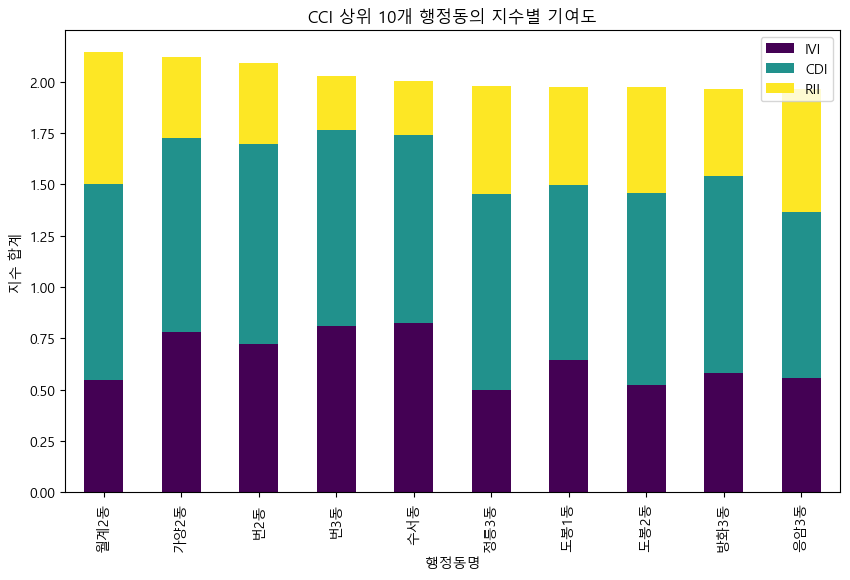

In [13]:
import matplotlib.pyplot as plt
import platform

# 1. 운영체제에 맞는 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우 맑은 고딕
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'  # 맥 애플고딕
else:
    plt.rcParams['font.family'] = 'NanumGothic'  # 리눅스 (나눔고딕)

# 2. 마이너스(-) 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# --- 여기서부터 기존 코드 ---
# CCI 상위 10개 행정동의 지수별 중첩 막대 그래프
top_10_plot = top_10_cci.set_index('행정동명')[['IVI', 'CDI', 'RII']]
top_10_plot.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('CCI 상위 10개 행정동의 지수별 기여도')
plt.ylabel('지수 합계')
plt.show()